In [4]:
!pip3 install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 207 kB/s eta 0:00:01
     |████████████████████████████████| 294 kB 15.3 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 18.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 83.5 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 29.5 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 17.0 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 31.2 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 43.4 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 93.9 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 2.7 MB/s eta 0:00:011
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [5]:
# Once installed, we 'import' them to make them active in our notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("All tools are loaded and ready to go!")

Matplotlib is building the font cache; this may take a moment.


All tools are loaded and ready to go!


In [6]:
import pandas as pd
import numpy as np

# 1. Generate 365 days of dates for the year 2023
dates = pd.date_range(start="2023-01-01", end="2023-12-31", freq="D")

# 2. Create some realistic-looking fake data using a bit of math
np.random.seed(42) # This ensures we both get the exact same "random" numbers
# Simulating demand (Volume in MegaWatts) with seasonal waves
volume = 5000 + np.sin(dates.month / 12 * 2 * np.pi) * 1500 + np.random.normal(0, 400, len(dates))
# Simulating price (Rupees per MegaWatt hour) based on the volume
price = 2500 + (volume * 0.6) + np.random.normal(0, 300, len(dates))

# 3. Put it all into a Pandas 'DataFrame' (think of this as a virtual Excel table)
mock_data = pd.DataFrame({
    'Date': dates,
    'Volume_MW': volume.round(2),
    'Price_INR': price.round(2)
})

# 4. Save this table as a CSV file on your computer
mock_data.to_csv('iex_sample_data.csv', index=False)

print("Success! 'iex_sample_data.csv' has been created in your folder.")

Success! 'iex_sample_data.csv' has been created in your folder.


In [7]:
# Read the CSV file we just created into a DataFrame. 
# We usually name it 'df' for short.
df = pd.read_csv('iex_sample_data.csv')


# .head() showcs us the first 5 rows of our data so we can see what it looks like
print("Here are the first 5 rows of our dataset:")
display(df.head())

# .info() gives us a summary of the columns and data types
print("\n--- Dataset Info ---")
df.info()

Here are the first 5 rows of our dataset:


,Date,Volume_MW,Price_INR
0,2023-01-01,5948.69,5948.85
1,2023-01-02,5694.69,5984.04
2,2023-01-03,6009.08,6109.22
3,2023-01-04,6359.21,6344.83
4,2023-01-05,5656.34,5661.90



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       365 non-null    datetime64[ns]
 1   Volume_MW  365 non-null    float64       
 2   Price_INR  365 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 8.7 KB


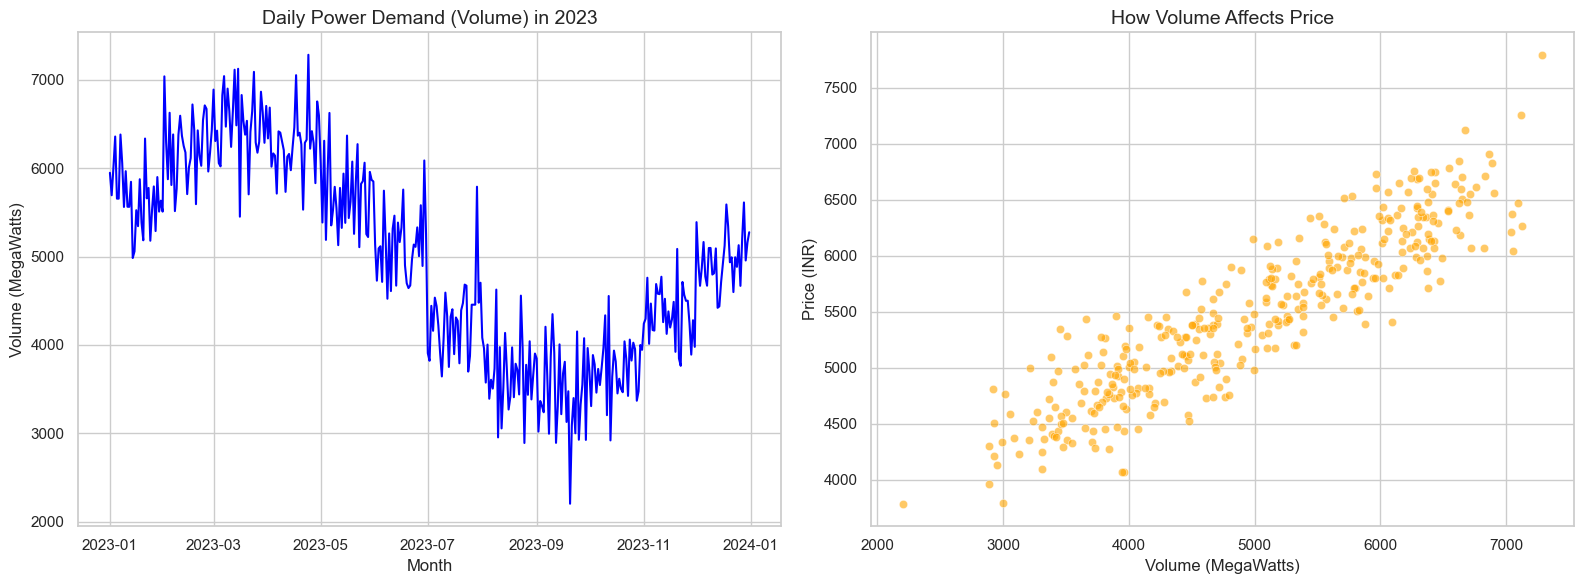

In [8]:
# Set the overall style for our charts to make them look professional
sns.set_theme(style="whitegrid")

# Create a large figure area to hold two charts side-by-side
plt.figure(figsize=(16, 6))

# --- CHART 1: Demand Over Time (Seasonality) ---
# We use subplot(1, 2, 1) which means: 1 row, 2 columns, this is the 1st chart
plt.subplot(1, 2, 1) 
sns.lineplot(data=df, x='Date', y='Volume_MW', color='blue')
plt.title('Daily Power Demand (Volume) in 2023', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Volume (MegaWatts)')

# --- CHART 2: Volume vs. Price (For Linear Regression) ---
# subplot(1, 2, 2) means: 1 row, 2 columns, this is the 2nd chart
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Volume_MW', y='Price_INR', color='orange', alpha=0.6)
plt.title('How Volume Affects Price', fontsize=14)
plt.xlabel('Volume (MegaWatts)')
plt.ylabel('Price (INR)')

# This command tells Jupyter to neatly display the charts now
plt.tight_layout()
plt.show()

In [9]:
# 1. Separate the "Feature" (X) from the "Target" (y)
X = df[['Volume_MW']] # Notice the double brackets! This keeps it formatted as a table
y = df['Price_INR']   # Single brackets because it's just one list of answers

# 2. Split the data into Training (80%) and Testing (20%) sets
# random_state=42 just ensures that the "random" split is the exact same every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Let's verify how many days went into each pile!
print("--- Data Split Complete ---")
print(f"Total days of data: {len(X)}")
print(f"Days used for Training (studying): {len(X_train)}")
print(f"Days used for Testing (the final exam): {len(X_test)}")

--- Data Split Complete ---
Total days of data: 365
Days used for Training (studying): 292
Days used for Testing (the final exam): 73


In [10]:
# 1. Bring in the "brain" - our Linear Regression model
model = LinearRegression()

# 2. Train the model (This is the actual "machine learning" part!)
# We give it the study material: Volume (X_train) and the actual Price (y_train)
model.fit(X_train, y_train)

# 3. Time for the final exam! 
# We give it the Testing data (X_test), which only has Volume, and ask it to guess the Price
predicted_prices = model.predict(X_test)

# 4. Let's create a quick side-by-side comparison of the first 5 guesses
# against the actual hidden prices to see how it did.
results = pd.DataFrame({
    'Actual_Price': y_test.values[:5].round(2), # The real hidden answers
    'Predicted_Price': predicted_prices[:5].round(2) # The model's guesses
})

print("Model Training Complete! Here is a sneak peek at the exam results:")
display(results)

Model Training Complete! Here is a sneak peek at the exam results:


,Actual_Price,Predicted_Price
0,4869.36,4763.91
1,5991.21,5997.41
2,5563.13,5793.67
3,4579.22,5006.29
4,6130.52,6171.26


--- Final Exam Results ---
Average Error (RMSE): ₹302.18 per MegaWatt hour
Model Accuracy Score (R-squared): 0.84 (Out of 1.0)


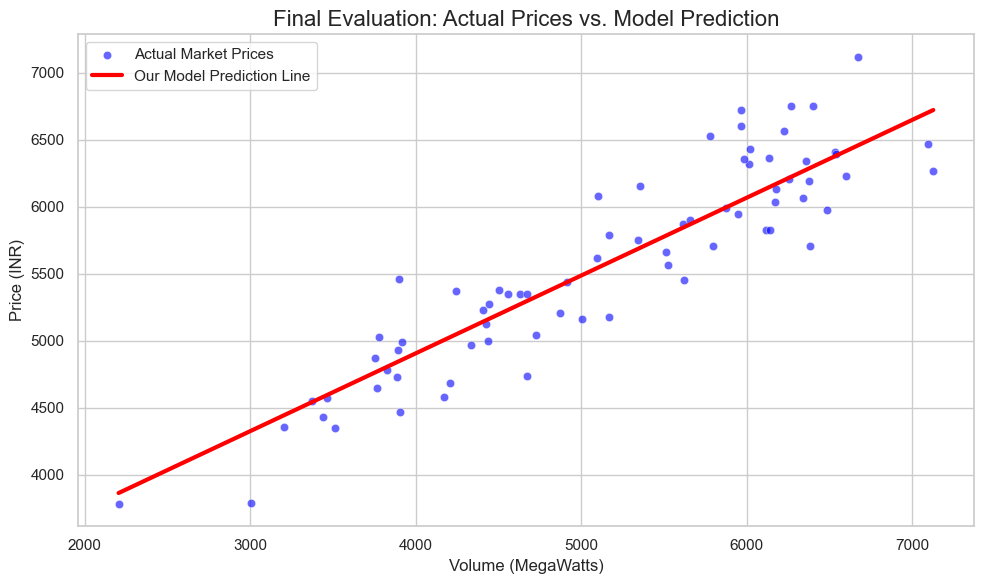

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calculate the 'Grades'
mse = mean_squared_error(y_test, predicted_prices)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, predicted_prices)

print("--- Final Exam Results ---")
# FIX: Using Python's built-in round() function wrapped around the variables
print(f"Average Error (RMSE): ₹{round(rmse, 2)} per MegaWatt hour")
print(f"Model Accuracy Score (R-squared): {round(r2, 2)} (Out of 1.0)")

# 2. Draw the Final Chart
plt.figure(figsize=(10, 6))

# Plot the real testing data points
sns.scatterplot(x=X_test['Volume_MW'], y=y_test, color='blue', alpha=0.6, label='Actual Market Prices')

# Plot the straight red line that our model calculated!
sns.lineplot(x=X_test['Volume_MW'], y=predicted_prices, color='red', linewidth=3, label='Our Model Prediction Line')

plt.title('Final Evaluation: Actual Prices vs. Model Prediction', fontsize=16)
plt.xlabel('Volume (MegaWatts)')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()